# Hackaton 02/20

your team members

*Team Member: Pablo Ruiz Crespo*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Task 1

A 1D rod of length $L=1$ has fixed end temperatures $T(0)=0$ and $T(1)=0$. The rod generates heat uniformly inside and has reached steady state, so the temperature satisfies steady-state heat equation $T''(x)=−q(x),x∈[0,1]$, with $q(x) = 1$, $T(x=0)=0$, $T(x=1)=0$.

**Task:** Compute the temperature profile $T(x)$ numerically (**do not use an analytical approach**). You may use **any computational approaches**. Plot the resulting $T(x)$ and briefly explain your method.


You may use external resources (Google, LLMs, etc.), but your proposed solution must be explained and justified. Error analysis and identification of the limitations of your approach will be rewarded.

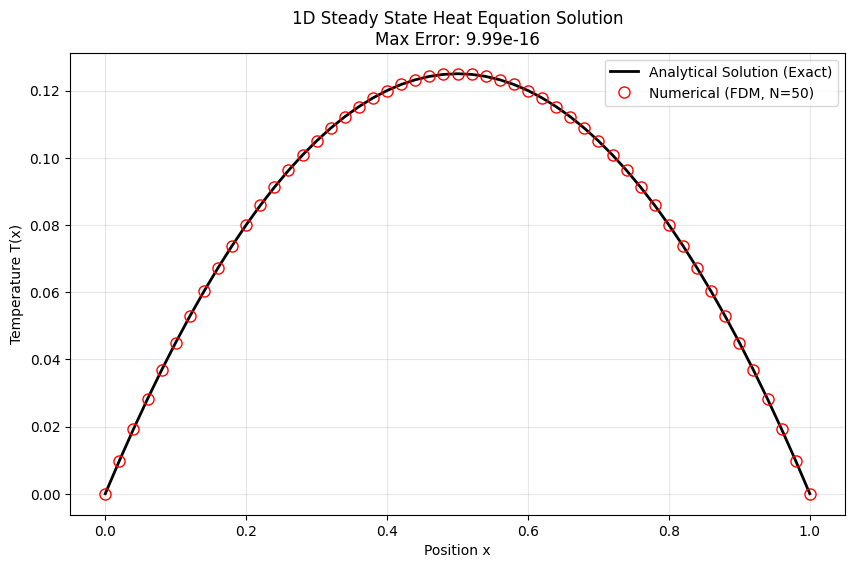

Max absolute error: 9.99201e-16


In [7]:
import numpy as np
import matplotlib.pyplot as plt

def solve_heat_equation(N=50):

    L = 1.0
    dx = L / N
    x = np.linspace(0, L, N+1)

    num_interior = N - 1

    main_diag = 2 * np.ones(num_interior)

    off_diag = -1 * np.ones(num_interior - 1)

    A = np.diag(main_diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)

    b = np.ones(num_interior) * (dx**2)

    # 3. Apply Boundary Conditions to b (Dirichlet)
    b[0] += 0
    b[-1] += 0

    T_interior = np.linalg.solve(A, b)
    T_numerical = np.concatenate(([0], T_interior, [0]))

    return x, T_numerical


N = 50

# Numerical Solution
x_num, T_num = solve_heat_equation(N)

# Analytical Solution (Exact)
T_exact = 0.5 * x_num * (1 - x_num)

# Error Calculation
error = np.abs(T_num - T_exact)
max_error = np.max(error)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_num, T_exact, 'k-', linewidth=2, label='Analytical Solution (Exact)')
plt.plot(x_num, T_num, 'ro', fillstyle='none', markersize=8, label=f'Numerical (FDM, N={N})')

plt.title(f'1D Steady State Heat Equation Solution\nMax Error: {max_error:.2e}')
plt.xlabel('Position x')
plt.ylabel('Temperature T(x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Max absolute error: {max_error:.5e}")

### Task 2

Nonlinear heat conduction. The same rod but now temperature satisfies $T''(x)=-T(x)^3,x∈[0,1]$, $T(0)=0$, $T(1)=0$.

Converged in 3 iterations. Residual: 6.37e-12


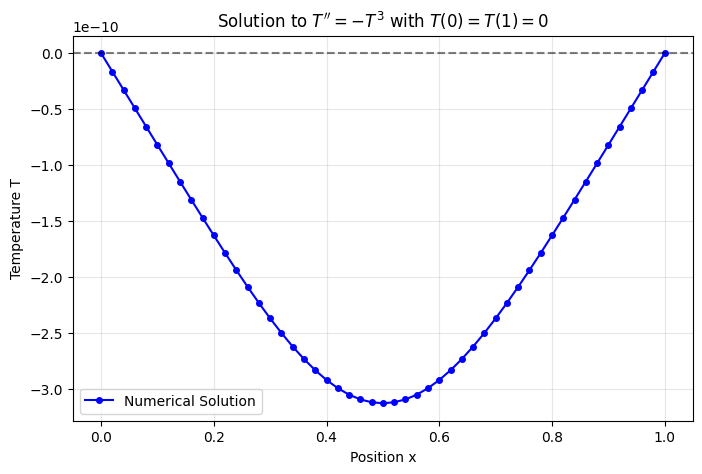

Max T: 0.00000


In [8]:
import numpy as np
import matplotlib.pyplot as plt

def solve_nonlinear_heat(N=50, tolerance=1e-6, max_iter=20):

    L = 1.0
    h = L / N
    x = np.linspace(0, L, N+1)



    T_interior = np.sin(np.pi * x[1:-1])
    num_interior = N - 1

    for k in range(max_iter):


        T_full = np.concatenate(([0], T_interior, [0]))

        F = (T_full[:-2] - 2*T_full[1:-1] + T_full[2:]) + h**2 * (T_full[1:-1]**3)

        res_norm = np.linalg.norm(F)
        if res_norm < tolerance:
            print(f"Converged in {k} iterations. Residual: {res_norm:.2e}")
            break


        main_diag = -2 + 3 * h**2 * (T_interior**2)
        off_diag = np.ones(num_interior - 1)

        J = np.diag(main_diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)

        delta_T = np.linalg.solve(J, -F)

        T_interior += delta_T

    else:
        print("Did not converge within max iterations.")

    return x, np.concatenate(([0], T_interior, [0]))

x, T = solve_nonlinear_heat(N=50)

plt.figure(figsize=(8, 5))
plt.plot(x, T, 'b-o', markersize=4, label="Numerical Solution")
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.title(r"Solution to $T'' = -T^3$ with $T(0)=T(1)=0$")
plt.xlabel("Position x")
plt.ylabel("Temperature T")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Max T: {np.max(T):.5f}")

### Task 3

Inverse problem. $T''(x)=-q(x),x∈[0,1]$, $T(x=0)=0$, $T(x=1)=0$.
The temperature is measured in the several points (see below).

**Task:** Can you reconstruct $q(x)$?




In [9]:
# measurement locations
x_meas = np.array([
    0, 0.05, 0.20, 0.30, 0.40,
    0.60, 0.70, 0.80, 0.95, 1
])

# measured temperatures (synthetic data)
T_meas = np.array([
    0,
    0.0228,
    0.0832,
    0.1121,
    0.1336,
    0.1324,
    0.1073,
    0.0704,
    0.0158,
    0,
])

Text(0, 0.5, 'T')

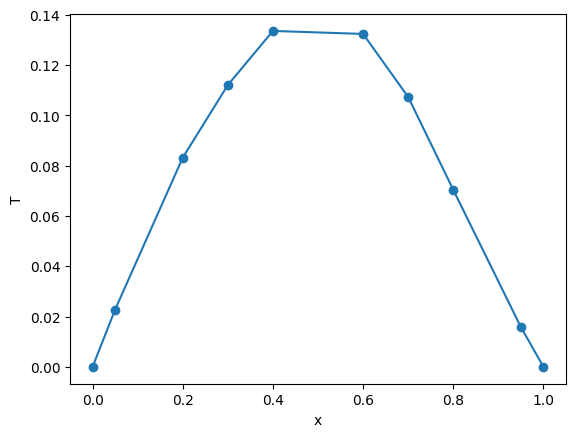

In [10]:
plt.plot(x_meas, T_meas, 'o-')
plt.xlabel('x')
plt.ylabel('T')

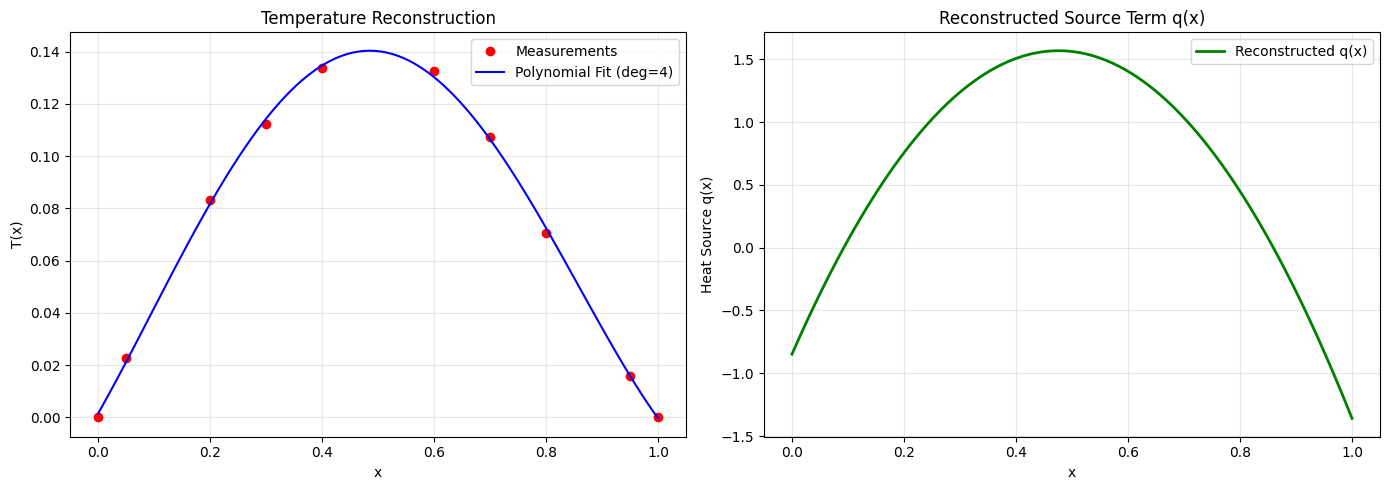

Reconstructed q(x) polynomial coefficients (highest degree first):
[-10.66006966  10.14920609  -0.84818841]


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d





degree = 4
coeffs = np.polyfit(x_meas, T_meas, degree)
poly_T = np.poly1d(coeffs)

poly_dT = np.polyder(poly_T, 1)
poly_d2T = np.polyder(poly_T, 2)

def q_reconstructed(x):
    return -poly_d2T(x)

x_dense = np.linspace(0, 1, 100)
T_fit = poly_T(x_dense)
q_fit = q_reconstructed(x_dense)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(x_meas, T_meas, 'ro', label='Measurements')
ax[0].plot(x_dense, T_fit, 'b-', label=f'Polynomial Fit (deg={degree})')
ax[0].set_title("Temperature Reconstruction")
ax[0].set_xlabel("x")
ax[0].set_ylabel("T(x)")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(x_dense, q_fit, 'g-', linewidth=2, label="Reconstructed q(x)")
ax[1].set_title("Reconstructed Source Term q(x)")
ax[1].set_xlabel("x")
ax[1].set_ylabel("Heat Source q(x)")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Reconstructed q(x) polynomial coefficients (highest degree first):")
print(-poly_d2T.c)